# PRÁCTICA MACHINE LEARNING

## Graph Classification with Graph Neural Networks. Dataset: MUTAG

Profesor: Francisco Escolano

Alumno: Nicolás Vives Vicente

La tarea más común para la clasificación de grafos es la **predicción de propiedades moleculares**, en la que las moléculas se representan como grafos, y la tarea puede consistir en inferir si una molécula inhibe la replicación del virus del VIH o no.

La Universidad Técnica de Dortmund ha recopilado una amplia gama de diferentes conjuntos de datos de clasificación de grafos, conocidos como [**TUDatasets**](https://chrsmrrs.github.io/datasets/), los cuales también son accesibles a través de [`torch_geometric.datasets.TUDataset`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset) en PyTorch Geometric.

En este notebook se estudia uno de los más pequeños, el **conjunto de datos MUTAG**:

## Librerías necesarias:

In [8]:
# Librerías Estándar de Python
import os
import csv
import random
from collections import Counter

# Análisis de Datos, Grafos y Visualización
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn.functional as F
from torch.nn import Linear

# PyTorch Geometric (Utilidades)
import torch_geometric.data
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx, to_dense_batch, to_dense_adj

# PyTorch Geometric (Capas GNN y Pooling)
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool  # Global Mean Pooling
from torch_geometric.nn import global_add_pool   # Global Add Pooling
from torch_geometric.nn import global_max_pool   # Global Max Pooling

# Modelo Net
from torch_geometric.nn import dense_mincut_pool, DenseGraphConv

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Inspección del dataset:

In [9]:
dataset = TUDataset(root='data/TUDataset', name='MUTAG')

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Extraemos las etiquetas (y) de cada grafo y las contamos
labels = [data.y.item() for data in dataset]
class_counts = Counter(labels)

print('====================')
print('Samples per class:')
for cls, count in sorted(class_counts.items()):
    print(f' - Class {cls}: {count}')
print('====================')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: MUTAG(188):
Number of graphs: 188
Number of features: 7
Number of classes: 2
Samples per class:
 - Class 0: 63
 - Class 1: 125

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Number of nodes: 17
Number of edges: 38
Average node degree: 2.24
Has isolated nodes: False
Has self-loops: False
Is undirected: True


Este conjunto de datos proporciona **188 grafos diferentes**, y la tarea consiste en clasificar cada grafo en **una de dos clases**. La clase 0 tiene 63 grafos y la clase 1 125, por lo que están algo desbalanceadas.

Al inspeccionar el primer objeto de grafo del conjunto de datos, podemos ver que cuenta con **17 nodos (con vectores de características de 7 dimensiones)** y **38 aristas** (lo que resulta en un grado promedio de nodo de 2.24).
También cuenta con exactamente **una etiqueta de grafo** (`y=[1]`) y proporciona **características de arista de 4 dimensiones** adicionales (`edge_attr=[38, 4]`).
Sin embargo, no haremos uso de estas últimas.

Como tenemos dos clases, veamos un ejemplo de molécula perteneciente a cada una de ellas.

tensor([0])
tensor([1])


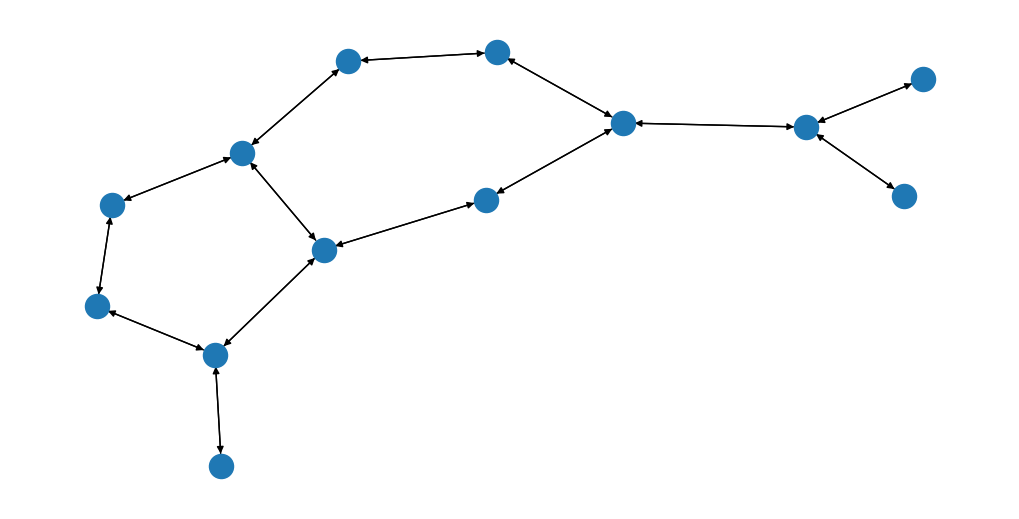

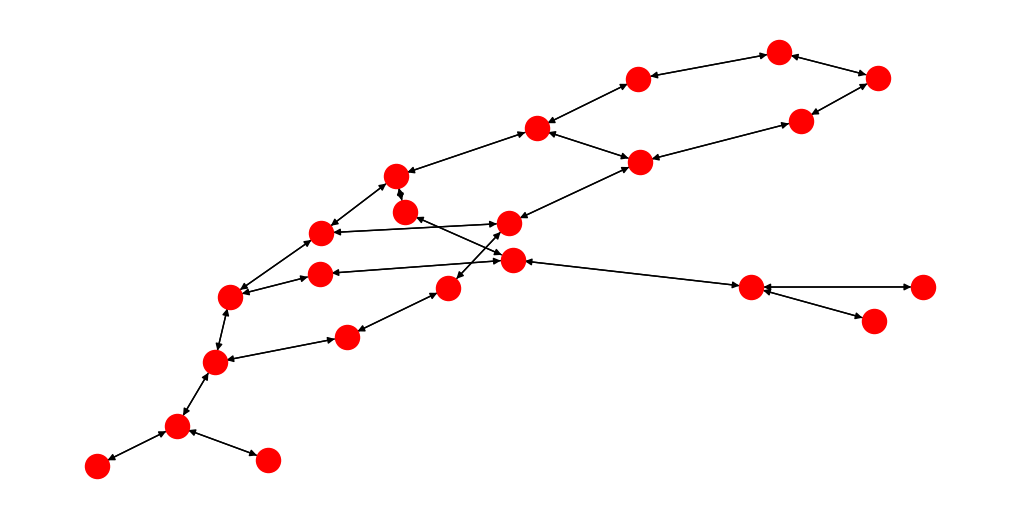

In [10]:
data = random.choice([t for t in dataset if t.y==0])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g)
print(data.y)

data = random.choice([t for t in dataset if t.y==1])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g,node_color='r')
print(data.y)


Antes de comenzar con el entrenamiento y evaluación de los modelos conviene mencionar que se han detectado algunos problemas en el código proporcionado para la práctica y se han solucionado de la siguiente forma:

- Cálculo Aislado del Espectro Laplaciano (Graph-by-Graph):

    - Problema: Calcular el Laplaciano sobre el batch completo genera un grafo enorme, con tantas componentes desconectadas como moléculas haya en el lote. Matemáticamente, esto produce un autovalor igual a cero por cada componente. Al seleccionar los $k$ primeros, estos ceros acaparan la selección, entregando a la red autovectores vacíos que hacen inútil la geometría espacial y disparan el coste computacional al operar sobre una matriz gigante.

    - Solución implementada: Se ha aplicado una estrategia de "divide y vencerás", modificando la función para que desempaquete el lote y calcule el Laplaciano molécula por molécula de forma estrictamente individual. Esto garantiza un único autovalor cero por grafo, permitiendo que el resto de los $k$ autovectores extraigan correctamente las auténticas frecuencias estructurales y formas tridimensionales, reduciendo además la complejidad computacional.

- Corrección del Bucle de Validación (DataLoaders y Reproducibilidad):

    - Problema: La evaluación de modelos (incluyendo la red base Net) estaba consumiendo DataLoaders instanciados globalmente al inicio del notebook. Esto provocaba que, aunque los modelos variaran sus pesos iniciales y por tanto sí daban resultados distintos, no se estaba respetando la semilla de reproducibilidad para la partición de datos en las distintas iteraciones.

    - Solución implementada: Se ha reestructurado el bucle principal de evaluación. Ahora, la división del dataset y la generación de los train_loader y test_loader se ejecutan internamente en cada iteración, garantizando que los datos de entrenamiento y prueba cambien respetando la partición de los datos según la semilla activa.

Funciones heredadas con las modificaciones aplicadas:

In [11]:
def compute_laplacian_eigenvectors_pytorch(data, k):
    # 1. Convert PyTorch Geometric graph to NetworkX graph
    g = to_networkx(data, to_undirected=True)

    # 2. Compute the normalized Laplacian matrix using NetworkX
    # networkx.normalized_laplacian_matrix returns a sparse matrix
    # Then we make it dense and compatible with numpy
    L = nx.normalized_laplacian_matrix(g).todense()

    # 3. Finding eigen values and eigen vectors
    e, evecs = np.linalg.eig(L)
    #e.shape, evecs.shape

    # 4. Sort eigenvectors
    # Sort them (both e's and evecs's) ascending
    idx =e.argsort()
    e = e[idx]
    evecs = evecs[:,idx]

    # 3. Convert the sparse Laplacian matrix to a dense PyTorch tensor
    # Convert to dense numpy array first, then to torch tensor
    evecs_torch = torch.tensor(np.real(evecs[:,:k]), dtype=torch.float32)

    return evecs_torch

# Train and test functions. Use k=0 when no spectral info
def train(model, train_loader, optimizer, k):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for data in train_loader:  # Iterate in batches over the training dataset.
        optimizer.zero_grad()
        # Ensure all data components are on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)
        data.batch = data.batch.to(device)

        # MODIFICACIÓN NICOLÁS VIVES
        if k > 0:
            evecs_list = []
            # Desempaquetamos el batch en grafos individuales
            for single_graph in data.to_data_list():
                # Calculamos el Laplaciano molécula por molécula
                evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                evecs_list.append(evecs_single)
            
            # Volvemos a unir los resultados en un solo tensor y lo pasamos a la GPU
            evecs_torch = torch.cat(evecs_list, dim=0).to(device)
            # Concatenamos con las características originales
            data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN NICOLÁS VIVES

        # Pass data components to the model
        out = model(data.x, data.edge_index, data.batch)

        loss = criterion(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.

        total_loss += loss.item() * data.y.size(0)
        pred = out.argmax(dim=1)
        total_correct += (pred == data.y).sum().item()
        total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def test(model, loader, k):
    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for data in loader:  # Iterate in batches over the training/test dataset.
            # Ensure all data components are on the correct device
            data.x = data.x.to(device)
            data.edge_index = data.edge_index.to(device)
            data.y = data.y.to(device)
            data.batch = data.batch.to(device)

        # MODIFICACIÓN NICOLÁS VIVES
            if k > 0:
                evecs_list = []
                for single_graph in data.to_data_list():
                    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                    evecs_list.append(evecs_single)
                
                evecs_torch = torch.cat(evecs_list, dim=0).to(device)
                data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN NICOLÁS VIVES

            out = model(data.x, data.edge_index, data.batch)

            loss = criterion(out, data.y) # Compute the loss.
            total_loss += loss.item() * data.y.size(0)

            pred = out.argmax(dim=1)  # Use the class with highest probability.
            total_correct += int((pred == data.y).sum())  # Check against ground-truth labels.
            total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def split(dataset, seed):
  torch.manual_seed(seed)
  dataset = dataset.shuffle()

  # Get 25% approx per test
  split_idx = int(len(dataset) * 0.75)
  print("split idx", split_idx)

  train_dataset = dataset[:split_idx]
  test_dataset = dataset[split_idx:]

  #print(f'Number of training graphs: {len(train_dataset)}')
  #print(f'Number of test graphs: {len(test_dataset)}')
  return train_dataset, test_dataset

## Experimento 1: Evaluación de arquitecturas base

En esta fase inicial establecemos las líneas base para el dataset **MUTAG**. El objetivo es clasificar las moléculas comparando tres estrategias de integración de información, manteniendo los parámetros del *notebook* original.

### Configuración experimental

Para equilibrar la capacidad expresiva y evitar el sobreajuste en este dataset de dimensiones reducidas, se aplicarán los siguientes hiperparámetros:

| Hiperparámetro | Valor |
| :--- | :--- |
| Canales Ocultos (*Hidden Channels*) | 64 |
| Número de Capas Convolucionales | 3 |
| Resolución Espectral ($k$) | 4 |
| Tipo de Agregación (*Pooling*) | Global Mean Pool |

In [12]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(11, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [21]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Mean Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_MUTAG.csv")
        with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 141
Epoch: 001, Loss: 0.65403, Train Acc: 0.62411
Epoch: 002, Loss: 0.62986, Train Acc: 0.68085
Epoch: 003, Loss: 0.61915, Train Acc: 0.68085
Epoch: 004, Loss: 0.61608, Train Acc: 0.68085
Epoch: 005, Loss: 0.59777, Train Acc: 0.68085
Epoch: 006, Loss: 0.60045, Train Acc: 0.68085
Epoch: 007, Loss: 0.60247, Train Acc: 0.68085
Epoch: 008, Loss: 0.59039, Train Acc: 0.68085
Epoch: 009, Loss: 0.56736, Train Acc: 0.68085
Epoch: 010, Loss: 0.57876, Train Acc: 0.68794
Epoch: 011, Loss: 0.55101, Train Acc: 0.73759
Epoch: 012, Loss: 0.54244, Train Acc: 0.70922
Epoch: 013, Loss: 0.55129, Train Acc: 0.73759
Epoch: 014, Loss: 0.55261, Train Acc: 0.73050
Epoch: 015, Loss: 0.53910, Train Acc: 0.72340
Epoch: 016, Loss: 0.55587, Train Acc: 0.74468
Epoch: 017, Loss: 0.55272, Train Acc: 0.73050
Epoch: 018, Loss: 0.56046, Train Acc: 0.71631
Epoch: 019, Loss: 0.52854, Train Acc: 0.72340
Epoch: 020, Loss: 0.55391, Train Acc: 0.72340
Epo

Tras evaluar la configuración base utilizando 10 semillas aleatorias, se obtuvieron las métricas de precisión media (*Accuracy*) y desviación estándar (*Std*) tanto para el conjunto de entrenamiento como para el de validación.

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Mean | 0 | $76.88 \pm 1.74$ | $74.04 \pm 5.19$ |
| **GCNEig** | 64 | 3 | Mean | 4 | $92.62 \pm 2.12$ | $\mathbf{80.21 \pm 5.94}$ |
| **GCNEigDec.** | 64 | 3 | Mean | 4 | $86.38 \pm 3.53$ | $78.72 \pm 5.40$ |

* **Mejor Modelo:** Bajo esta configuración, el modelo `GCNEig` ofrece el mejor rendimiento general, siendo el único en superar el **80% de precisión** en el conjunto de validación (*Test Accuracy*).
* **Comparativa Espectral:** `GCNEig` supera consistentemente a la variante desacoplada (`GCNEigDec.`), lo que demuestra la efectividad de su estrategia de integración de información espectral para el dataset MUTAG.

## Experimento 2: Global Add Pool

Una vez que tenemos un baseline en el que fijarnos podemos variar diferentes parámetros y configuraciones para tratar de mejorar el modelo.

En esta fase se mantienen las arquitecturas y la capacidad expresiva del experimento anterior, variando únicamente el método de agregación global para evaluar su impacto en la clasificación.

Se modifica el tipo de agregación a una de carácter aditivo (**Global Add Pool**), conservando el resto de los hiperparámetros base:

| Hiperparámetro | Valor |
| :--- | :--- |
| Canales Ocultos (*Hidden Channels*) | 64 |
| Número de Capas Convolucionales | 3 |
| Resolución Espectral ($k$) | 4 |
| Tipo de Agregación (*Pooling*) | **Global Add Pool** |

MUTAG es un problema de predicción de propiedades químicas (mutagenicidad). En química, una molécula suele ser tóxica por la presencia de una subestructura específica (como un grupo funcional nitro o un anillo aromático), no por el "promedio" de sus átomos. Al utilizar global_mean_pool, la señal de ese átomo peligroso se puede diluirse al hacer la media con el resto de la molécula. Podemos pensar que utilizar la suma (add) o el máximo (max) podría retener mucho mejor la señal de la existencia del grupo peligroso en algún lugar del grafo.

In [14]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(11, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [34]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Add Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_MUTAG.csv")
        with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 141
Epoch: 001, Loss: 0.93264, Train Acc: 0.62411
Epoch: 002, Loss: 0.73460, Train Acc: 0.49645
Epoch: 003, Loss: 0.64221, Train Acc: 0.62411
Epoch: 004, Loss: 0.59639, Train Acc: 0.68085
Epoch: 005, Loss: 0.58840, Train Acc: 0.68085
Epoch: 006, Loss: 0.57970, Train Acc: 0.68085
Epoch: 007, Loss: 0.57407, Train Acc: 0.67376
Epoch: 008, Loss: 0.54290, Train Acc: 0.68794
Epoch: 009, Loss: 0.56872, Train Acc: 0.68085
Epoch: 010, Loss: 0.55422, Train Acc: 0.70922
Epoch: 011, Loss: 0.53672, Train Acc: 0.68794
Epoch: 012, Loss: 0.52380, Train Acc: 0.68085
Epoch: 013, Loss: 0.54572, Train Acc: 0.70922
Epoch: 014, Loss: 0.55296, Train Acc: 0.71631
Epoch: 015, Loss: 0.52042, Train Acc: 0.71631
Epoch: 016, Loss: 0.53018, Train Acc: 0.68085
Epoch: 017, Loss: 0.51135, Train Acc: 0.73050
Epoch: 018, Loss: 0.52813, Train Acc: 0.73759
Epoch: 019, Loss: 0.50559, Train Acc: 0.74468
Epoch: 020, Loss: 0.52036, Train Acc: 0.74468
Epo

La utilización de la capa de agregación aditiva (`Global Add Pool`) modificó el comportamiento de los modelos, dando las siguientes métricas:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Add | 0 | $79.71 \pm 1.99$ | $76.17 \pm 5.19$ |
| **GCNEig** | 64 | 3 | Add | 4 | $94.76 \pm 2.64$ | $78.51 \pm 4.16$ |
| **GCNEigDec.** | 64 | 3 | Add | 4 | $86.60 \pm 3.21$ | $\mathbf{80.00 \pm 4.58}$ |

* **Impacto Positivo de la Suma (`GCN` y `GCNEigDec.`):** Ambos modelos experimentaron una mejora en su precisión de prueba, alcanzando un **76.17%** y **80.00%** respectivamente.
* **Degradación en Fusión Temprana (`GCNEig`):** Este modelo redujo su capacidad con la capa *Add*. La combinación directa de coordenadas geométricas y propiedades químicas en un mismo espacio latente desde la primera capa puede generar interferencias, requiriendo un filtro de suavizado como `Mean Pool` para preservar la estabilidad.

Estos resultados motivan el **Experimento 3**, donde se probará un filtro completamente selectivo (`Global Max Pool`). El objetivo es evaluar si es posible aislar la señal de toxicidad.

## Experimento 3: Global Max Pool

Al igual que la agregación por suma, la *Global Max Pool* busca evitar la posible dilución de la señal química que se puede dar con el promedio. 

Mientras que la suma acumula evidencias, el máximo retiene únicamente la activación más fuerte detectada en cualquier nodo del grafo. En términos bioquímicos, esto puede ayudar a la red a identificar si existe al menos una subestructura cuya toxicidad sea lo suficientemente dominante como para determinar la mutagenicidad de la molécula completa,

In [15]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(11, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [45]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_MUTAG.csv")
        with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 141
Epoch: 001, Loss: 0.65431, Train Acc: 0.68794
Epoch: 002, Loss: 0.63093, Train Acc: 0.68085
Epoch: 003, Loss: 0.62297, Train Acc: 0.68085
Epoch: 004, Loss: 0.62178, Train Acc: 0.68085
Epoch: 005, Loss: 0.60641, Train Acc: 0.68085
Epoch: 006, Loss: 0.60556, Train Acc: 0.68085
Epoch: 007, Loss: 0.61189, Train Acc: 0.68085
Epoch: 008, Loss: 0.60981, Train Acc: 0.68085
Epoch: 009, Loss: 0.58175, Train Acc: 0.68085
Epoch: 010, Loss: 0.58380, Train Acc: 0.68085
Epoch: 011, Loss: 0.55530, Train Acc: 0.68794
Epoch: 012, Loss: 0.54927, Train Acc: 0.67376
Epoch: 013, Loss: 0.55929, Train Acc: 0.74468
Epoch: 014, Loss: 0.57070, Train Acc: 0.69504
Epoch: 015, Loss: 0.54511, Train Acc: 0.73759
Epoch: 016, Loss: 0.56550, Train Acc: 0.72340
Epoch: 017, Loss: 0.57071, Train Acc: 0.72340
Epoch: 018, Loss: 0.54661, Train Acc: 0.73759
Epoch: 019, Loss: 0.53354, Train Acc: 0.75177
Epoch: 020, Loss: 0.56812, Train Acc: 0.73759
Epo

La evaluación del criterio de agregación por máximo (`Global Max Pool`) nos dió las siguientes métricas de rendimiento:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Max | 0 | $77.80 \pm 2.22$ | $74.68 \pm 4.41$ |
| **GCNEig** | 64 | 3 | Max | 4 | $93.83 \pm 2.39$ | $78.51 \pm 4.41$ |
| **GCNEigDec.** | 64 | 3 | Max | 4 | $91.84 \pm 2.44$ | $76.38 \pm 5.90$ |

* Aunque el uso de `Global Max Pool` ofrece un rendimiento superior al promedio en el modelo base `GCN`, no logra igualar la precisión alcanzada mediante la agregación aditiva (`Add`) en las arquitecturas espectrales.
* Este comportamiento sugiere que la identificación de la mutagenicidad se beneficia en mayor medida de la **acumulación de evidencias** (representada por la suma) que de la detección de una única característica aislada (representada por el máximo).
* La caída de rendimiento es especialmente notable en el modelo `GCNEigDec.`, el cual sufre una pérdida de casi 4 puntos porcentuales en comparación con los resultados obtenidos con la agregación por suma.

## Experimento 4: Reducción de la profundidad

A partir de los hallazgos anteriores, se dividen las estrategias de agregación según lo que mejor funcionó para cada arquitectura: los modelos `GCN` y `GCNEigDec.` adoptan **Global Add Pool** (ya que la suma favorece la detección de toxicidad), mientras que `GCNEig` mantiene **Global Mean Pool**. 

Este experimento evalúa el impacto de la profundidad de la red, reduciendo la arquitectura de **3 a 2 capas convolucionales**.

Los parámetros se ajustan de forma individualizada para cada modelo, manteniendo una salida latente de 64 dimensiones:

| Modelo | Capas | Agregación (*Pooling*) | $k$ |
| :--- | :---: | :--- | :---: |
| **GCN** | 2 | Global Add Pool | 0 |
| **GCNEig** | 2 | Global Mean Pool | 4 |
| **GCNEigDecoupled** | 2 | Global Add Pool | 4 |

La reducción a 2 capas responde a una limitación crítica de las GNNs al trabajar con grafos pequeños (como las moléculas de MUTAG):

* **El problema (*Oversmoothing*):** Si una red es demasiado profunda en relación con el diámetro del grafo, los múltiples saltos de propagación provocan que la información de todos los nodos se mezcle de forma redundante. Como consecuencia, las representaciones latentes convergen hacia un mismo vector, impidiendo que la red distinga las diferentes partes y subestructuras de la molécula.
* **La solución:** Al reducir la profundidad a 2 capas, se busca evitar que se diluya la información local y facilitar que el modelo aprenda características estructurales diferenciadas y nítidas.

Para implementar la reducción de profundidad, se ha eliminado la capa intermedia del diseño original en todas las redes. 

En el caso específico del modelo **`GCNEigDecoupled`**, el flujo de información se ha reestructurado de la siguiente manera para equilibrar la importancia de las características:

* **Rama Convolucional (`conv1`):** Procesa y comprime las propiedades químicas de los nodos a un espacio de 32 dimensiones.
* **Rama Lineal (`lin2`):** Proyecta la información geométrica (coordenadas espaciales/espectrales) a otras 32 dimensiones.
* **Fusión (Concatenación):** Las salidas de ambas ramas se concatenan directamente, creando un tensor unificado de 64 dimensiones.
* **Capa Final (`conv2`):** Recibe este tensor combinado, garantizando que la red pondere con exactamente la misma relevancia tanto la química como la topología espacial antes de emitir la predicción.

In [16]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels // 2)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        x = self.conv2(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu()

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        x = self.conv2(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu()
        
        # Concatenate processed x and PE for the next conv layer
        #x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(11, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(7, 32)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [52]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 2

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Add Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 2:
        POOLING_TYPE = 'Global Add Pool'
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_MUTAG.csv")
        with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 141
Epoch: 001, Loss: 1.07344, Train Acc: 0.66667
Epoch: 002, Loss: 0.74804, Train Acc: 0.54610
Epoch: 003, Loss: 0.60137, Train Acc: 0.63121
Epoch: 004, Loss: 0.61480, Train Acc: 0.68085
Epoch: 005, Loss: 0.54212, Train Acc: 0.68085
Epoch: 006, Loss: 0.56342, Train Acc: 0.70922
Epoch: 007, Loss: 0.53884, Train Acc: 0.68794
Epoch: 008, Loss: 0.54362, Train Acc: 0.68794
Epoch: 009, Loss: 0.52836, Train Acc: 0.70922
Epoch: 010, Loss: 0.58303, Train Acc: 0.67376
Epoch: 011, Loss: 0.53834, Train Acc: 0.70213
Epoch: 012, Loss: 0.50751, Train Acc: 0.71631
Epoch: 013, Loss: 0.50690, Train Acc: 0.73759
Epoch: 014, Loss: 0.50344, Train Acc: 0.73759
Epoch: 015, Loss: 0.51944, Train Acc: 0.73050
Epoch: 016, Loss: 0.51146, Train Acc: 0.72340
Epoch: 017, Loss: 0.51054, Train Acc: 0.75177
Epoch: 018, Loss: 0.52601, Train Acc: 0.71631
Epoch: 019, Loss: 0.49798, Train Acc: 0.76596
Epoch: 020, Loss: 0.53790, Train Acc: 0.74468
Epo

Tras evaluar las arquitecturas limitando su profundidad a 2 capas convolucionales, se obtuvieron las siguientes métricas:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 2 | Add | 0 | $80.78 \pm 1.99$ | $74.89 \pm 4.83$ |
| **GCNEig** | 64 | 2 | Mean | 4 | $89.93 \pm 2.16$ | $77.45 \pm 4.87$ |
| **GCNEigDec.** | 64 | 2 | Add | 4 | $87.52 \pm 2.48$ | $77.87 \pm 4.87$ |

* Todos los modelos experimentaron una disminución en la precisión de prueba respecto a sus versiones de 3 capas. El modelo `GCNEig` descendió del **80.21% al 77.45%**, mientras que `GCNEigDecoupled` cayó del **80.00% al 77.87%**.
* Estos resultados descartan que la reducción de capas mejore el rendimiento por mitigación del *oversmoothing*. Al contrario, demuestran que 2 capas son **insuficientes** para que la red capture correctamente la topología de las moléculas de MUTAG.
* Aumentar la red a 4 capas implicaría que la información viaje de un extremo a otro de la molécula y vuelva, provocando que los nodos reciban información redundante y sus vectores se vuelvan idénticos. Por tanto, se concluye que una profundidad de **3 capas es el punto óptimo** de equilibrio.

Tras descartar la reducción de profundidad, se restablece el estándar de **3 capas**. El **Experimento 5** se enfocará en la capacidad de memoria de la red, evaluando el impacto de variar la dimensión oculta (*Hidden Dimensions*) entre **32 y 128 canales** para estudiar cómo afecta a la estabilización del aprendizaje.

### Experimento 5. *Hidden_channels*

Observemos los resultados de nuestros 3 mejores modelos hasta el momento.

| Modelo | Hidden Dim | Num Layers | Pooling Type | K value | Train Accuracy | Test Accuracy Mean + Std |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **GCN** | 64 | 3 | Global Add Pool | 0 | ~79,43 | 76.17 +- 5.19 |
| **GCNEig** | 64 | 3 | Global Mean Pool | 4 | ~90,78 | 80.21 +- 5.63 |
| **GCNEigDecoupled** | 64 | 3 | Global Add Pool | 4 | ~87,23 | 80 +- 4.58 |

Puesto que para el modelo **GCN** no existe apenas *overfitting* si no que se trata de una diferencia esperable entre el train y el test, podemos pensar que al modelo le falta capacidad para capturar las características de los datos, lo que motiva probar *hidden_channels* = 128.

Por otro lado, para los modelos **GCNEig** y **GCNEigDecoupled** se observa un claro *overfitting*, por lo que podemos pensar que modelos más simples pueden ser capaces de capturar las mismas características de los datos o incluso ser más precisos al no ajustarse tanto a los datos de entrenamiento. Este suceso nos motiva a probar *hidden_channels* = 32.

In [17]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=128,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(7, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(11, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(7, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


In [12]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Movemos el parámetro hidden_channels_val de aquí a dentro del bucle para distinguir los diferentes casos que queremos probar.
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Add Pool'
        hidden_channels_val = 128
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'
        hidden_channels_val = 32
    elif j == 2:
        POOLING_TYPE = 'Global Add Pool'
        hidden_channels_val = 32
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_MUTAG.csv")
        with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 141
Epoch: 001, Loss: 1.16625, Train Acc: 0.65957
Epoch: 002, Loss: 0.71117, Train Acc: 0.68085
Epoch: 003, Loss: 0.61069, Train Acc: 0.68085
Epoch: 004, Loss: 0.63097, Train Acc: 0.60993
Epoch: 005, Loss: 0.54628, Train Acc: 0.68085
Epoch: 006, Loss: 0.56802, Train Acc: 0.68085
Epoch: 007, Loss: 0.57961, Train Acc: 0.70213
Epoch: 008, Loss: 0.56292, Train Acc: 0.68085
Epoch: 009, Loss: 0.55569, Train Acc: 0.68085
Epoch: 010, Loss: 0.54690, Train Acc: 0.68794
Epoch: 011, Loss: 0.54211, Train Acc: 0.72340
Epoch: 012, Loss: 0.57594, Train Acc: 0.68794
Epoch: 013, Loss: 0.51896, Train Acc: 0.69504
Epoch: 014, Loss: 0.57522, Train Acc: 0.68085
Epoch: 015, Loss: 0.53150, Train Acc: 0.75177
Epoch: 016, Loss: 0.54398, Train Acc: 0.69504
Epoch: 017, Loss: 0.51426, Train Acc: 0.77305
Epoch: 018, Loss: 0.53320, Train Acc: 0.70922
Epoch: 019, Loss: 0.48633, Train Acc: 0.71631
Epoch: 020, Loss: 0.49276, Train Acc: 0.78723
Epo

El ajuste de la capacidad latente (dimensión oculta) ha demostrado ser una de las estrategias de optimización más efectivas para este dataset. Las métricas obtenidas se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 128 | 3 | Add | 0 | $80.63 \pm 1.46$ | $77.23 \pm 4.26$ |
| **GCNEig** | 32 | 3 | Mean | 4 | $91.42 \pm 2.33$ | $\mathbf{80.64 \pm 3.08}$ |
| **GCNEigDec.** | 32 | 3 | Add | 4 | $86.52 \pm 2.14$ | $79.57 \pm 3.71$ |

* Al elevar la arquitectura a 128 canales, el modelo base mejoró su precisión en prueba hasta el **77.23%** y redujo notablemente su variabilidad. Esto confirma que la red requería un mayor volumen de parámetros para procesar eficazmente la información.
* Reducir la dimensión a 32 canales no solo mantuvo el rendimiento en la barrera del **80%**, sino que alcanzó la **desviación estándar más baja de todo el estudio (3.08)**. Esto valida la hipótesis de que una representación latente más compacta actúa como un regularizador, haciendo al modelo menos sensible al ruido.
* Al bajar a 32 canales totales donde la información química y la geométrica se proyectan por separado en subespacios de 16 dimensiones el modelo mantuvo una precisión competitiva de **79.57%** y redujo considerablemente su desviación estándar (de 4.58 a 3.71), consolidándose como su configuración más óptima y eficiente hasta el momento.

Una vez fijadas las dimensiones óptimas (128 canales para `GCN` y 32 canales para las variantes espectrales), el **Experimento 6** concluirá la fase de pruebas sobre el dataset MUTAG evaluando el impacto del *Positional Encoding* mediante la variación paramétrica de la resolución espectral ($k$).

## Experimento 6: *Positional Encoding*

Con las arquitecturas óptimas ya fijadas (3 capas, 32 canales ocultos y *poolings* específicos), esta fase final sobre el dataset MUTAG evalúa cuánta información geométrica es necesaria para maximizar la capacidad predictiva. Para ello, se varía el hiperparámetro $k$ (número de autovectores del Laplaciano).

Dado el reducido tamaño de las moléculas en MUTAG, se prueban únicamente tres niveles de resolución geométrica:

* **$k=2$ (Baja resolución):** Considera únicamente la información topológica más importante.
* **$k=4$ (Resolución media):** El estándar que se ha estado evaluando hasta el momento.
* **$k=6$ (Alta resolución):** Introduce información posicional más detallada que, al tratarse de grafos pequeños, podría llegar a actuar como ruido.

In [13]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
        hidden_channels_val = 32
        k_val = 2
    elif j == 1:
        POOLING_TYPE = 'Global Add Pool'
        hidden_channels_val = 32
        k_val = 2
    if j == 2:
        POOLING_TYPE = 'Global Mean Pool'
        hidden_channels_val = 32
        k_val = 6
    elif j == 3:
        POOLING_TYPE = 'Global Add Pool'
        hidden_channels_val = 32
        k_val = 6
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_MUTAG.csv")
        with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 141
Epoch: 001, Loss: 0.65715, Train Acc: 0.61702
Epoch: 002, Loss: 0.63453, Train Acc: 0.68085
Epoch: 003, Loss: 0.61283, Train Acc: 0.68085
Epoch: 004, Loss: 0.60093, Train Acc: 0.68085
Epoch: 005, Loss: 0.61354, Train Acc: 0.68085
Epoch: 006, Loss: 0.57730, Train Acc: 0.68085
Epoch: 007, Loss: 0.60137, Train Acc: 0.68085
Epoch: 008, Loss: 0.56167, Train Acc: 0.68085
Epoch: 009, Loss: 0.58355, Train Acc: 0.68085
Epoch: 010, Loss: 0.58209, Train Acc: 0.68794
Epoch: 011, Loss: 0.56497, Train Acc: 0.69504
Epoch: 012, Loss: 0.55385, Train Acc: 0.73759
Epoch: 013, Loss: 0.55011, Train Acc: 0.75177
Epoch: 014, Loss: 0.51630, Train Acc: 0.73759
Epoch: 015, Loss: 0.52977, Train Acc: 0.70922
Epoch: 016, Loss: 0.52738, Train Acc: 0.74468
Epoch: 017, Loss: 0.51720, Train Acc: 0.73050
Epoch: 018, Loss: 0.53757, Train Acc: 0.74468
Epoch: 019, Loss: 0.49570, Train Acc: 0.76596
Epoch: 020, Loss: 0.52312, Train Acc: 0.75177


| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCNEig** | 32 | 3 | Mean | 2 | $89.79 \pm 2.37$ | $\mathbf{81.70 \pm 5.96}$ |
| **GCNEigDec.** | 32 | 3 | Add | 2 | $83.48 \pm 1.77$ | $76.38 \pm 3.36$ |
| **GCNEig** | 32 | 3 | Mean | 4 | $91.42 \pm 2.33$ | $80.64 \pm 3.08$ |
| **GCNEigDec.** | 32 | 3 | Add | 4 | $86.52 \pm 2.14$ | $\mathbf{79.57 \pm 3.71}$ |
| **GCNEig** | 32 | 3 | Mean | 6 | $94.61 \pm 3.70$ | $76.81 \pm 4.70$ |
| **GCNEigDec.** | 32 | 3 | Add | 6 | $89.50 \pm 2.67$ | $79.36 \pm 5.47$ |

La variación del parámetro $k$ muestra cómo cada arquitectura asimila y gestiona el ruido geométrico:

* **GCNEig (Fusión Temprana):** Alcanza su pico de precisión en prueba con $k=2$ (81.70%), lo que indica que solo requiere información topológica básica. Al incrementar a $k=6$, el rendimiento cae y el sobreajuste se dispara (Train: 94.61%). Como este modelo mezcla la geometría y la química en el mismo espacio latente desde la primera capa, carece de la capacidad para ignorar el ruido excesivo.
* **GCNEigDecoupled (Fusión Tardía):** Muestra el comportamiento opuesto respecto a la falta de datos. Con $k=2$ carece de información suficiente y sus resultados caen al 76.38%. Sin embargo, saturar la red con $k=6$ tampoco mejora la precisión obtenida con $k=4$ (79.57%) y, por el contrario, aumenta la inestabilidad (añadiendo casi 2 puntos de desviación estándar).

## Evaluación del modelo de referencia (`Net`)

Para concluir el análisis del dataset MUTAG, se ha ejecutado una prueba (*run*) del modelo de referencia `Net` utilizando la semilla de reproducibilidad 12345.

### Configuración del modelo

Este modelo incorpora una técnica de agrupamiento avanzada (`MinCut Pool`) y se configuró con los siguientes hiperparámetros:

* **Canales Ocultos (*Hidden Dim*):** 32
* **Número de Capas:** 2
* **Tipo de Agregación (*Pooling*):** MinCut Pool
* **Resolución Espectral ($k$):** 10

In [12]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels=32):
        super(Net, self).__init__()

        # GCN Layer - MLP - Dense GCN Layer
        self.conv1 = GCNConv(in_channels, hidden_channels)
        num_of_centers =  10 # k
        # The degree of the node belonging to any of the centers
        self.pool1 = Linear(hidden_channels, num_of_centers)
        self.conv2 = DenseGraphConv(hidden_channels, hidden_channels)
        # MLPs towards out
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)

        # Input: Batch of 20 graphs, each node F=3 features
        #        N1 + N2 + ... + N2 = 661
        # TSNE here?
    def forward(self, x, edge_index, batch):    # x torch.Size([661, 3]),  data.batch  torch.Size([661])
        # CONV1: Expand features from F=3 to F' = 32
        x = F.relu(self.conv1(x, edge_index))   # x torch.Size([661, 32])

        # Make all x_i of size N=MAX(N1,...,N20), e.g. N=40:
        x, mask = to_dense_batch(x, batch)      # x torch.Size([20, N, 32]) ; mask torch.Size([20, N]) batch_size=20
        #print("x size", x.size())

        # Make all adjacencies of size NxN
        adj = to_dense_adj(edge_index, batch)   # adj torch.Size([20, N, N])
        #print("adj_size", adj.size())

        # MLP of k=16 outputs s
        #print("adj_size", adj.size())
        s = self.pool1(x) # s torch.Size([20, N, k])
        #print("s_size", s.size())

        # MINCUT_POOL
        # Call to dense_cut_mincut_pool to get coarsened x, adj and the losses: k=16
        x, adj, mincut_loss, ortho_loss = dense_mincut_pool(x, adj, s, mask) # x torch.Size([20, 16, 32]),  adj torch.Size([20, 16, 16])
        #print("Coarsened x and adj sizes:", x.size(), adj.size())

        # CONV2: Now on coarsened x and adj:
        x = self.conv2(x, adj) #x torch.Size([20, 16, 32])
        #print("x_2 size", x.size())

        # Readout for each of the 20 graphs
        #x = x.mean(dim=1) # x torch.Size([20, 32])
        x = x.sum(dim=1) # x torch.Size([20, 32])
        #print("mean x_2 size", x.size())

        # Final MLP for graph classification: hidden channels = 32
        x = F.relu(self.lin1(x)) # x torch.Size([20, 32])
        #print("final x1 size", x.size())
        x = self.lin2(x) #x torch.Size([20, 2])
        #print("final x2 size", x.size())
        return F.log_softmax(x, dim=-1), mincut_loss , ortho_loss


In [13]:

def train_net(model, loader, optimizer, device):
    model.train()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # El modelo Net devuelve 3 valores
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Sumamos las funciones de pérdida
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss.backward()
        
        loss_all += data.y.size(0) * loss.item()
        optimizer.step()
        
        # Calculamos el accuracy de entrenamiento para el CSV
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

@torch.no_grad()
def test_net(model, loader, device):
    model.eval()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Pérdida en test
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss_all += data.y.size(0) * loss.item()
        
        # Accuracy en test
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

In [17]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 32
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_MUTAG.csv")
with open("resultados_MUTAG.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
    
    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
    
    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])
    
    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"
    
    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 141
Epoch: 001, Loss: 0.81380, Train Acc: 0.65248
Epoch: 010, Loss: 0.73101, Train Acc: 0.65248
Epoch: 020, Loss: 0.67211, Train Acc: 0.66667
Epoch: 030, Loss: 0.60388, Train Acc: 0.81560
Epoch: 040, Loss: 0.56283, Train Acc: 0.85816
Epoch: 050, Loss: 0.53529, Train Acc: 0.85106
Epoch: 060, Loss: 0.52827, Train Acc: 0.85106
Epoch: 070, Loss: 0.52709, Train Acc: 0.85106
Epoch: 080, Loss: 0.52013, Train Acc: 0.85816
Epoch: 090, Loss: 0.52773, Train Acc: 0.85106
Epoch: 100, Loss: 0.51888, Train Acc: 0.85816
Epoch: 110, Loss: 0.52177, Train Acc: 0.84397
Epoch: 120, Loss: 0.52128, Train Acc: 0.85816
Epoch: 130, Loss: 0.51478, Train Acc: 0.85816
Epoch: 140, Loss: 0.51197, Train Acc: 0.85816
Epoch: 150, Loss: 0.52057, Train Acc: 0.85816
Epoch: 160, Loss: 0.51021, Train Acc: 0.85816
Epoch: 170, Loss: 0.51170, Train Acc: 0.85816
Epoch: 180, Loss: 0.50809, Train Acc: 0.85816
Epoch: 190, Loss: 0.50548, Train Acc: 0.85816
Epoch: 200, Loss: 0.5013

La ejecución del modelo con la semilla indicada dió las siguientes métricas:

* **Precisión en Entrenamiento (*Train Accuracy*):** 85.82%
* **Precisión en Prueba (*Test Accuracy*):** 87.23%

* Este 87.23% es el mejor rendimiento registrado sobre el conjunto de datos MUTAG. Sirve para confirmar que aún existe un claro margen de mejora frente a la barrera del ~80% que logramos con nuestras redes espectrales.
* El éxito de `Net` no recae en un solo parámetro, sino en su diseño. Mientras que nuestros modelos colapsan toda la información en un solo paso al final de la red, `Net` utiliza un agrupamiento jerárquico, fusionando los nodos de las moléculas paso a paso.

## Resultados finales y conclusiones: MUTAG

Tras completar la fase de experimentación, en esta sección se resumen los hallazgos principales y se analiza el comportamiento de las arquitecturas mediante la visualización de sus espacios latentes.

En la siguiente tabla se presentan las configuraciones óptimas alcanzadas para cada tipo de red:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 128 | 3 | Add | 0 | $80.63 \pm 1.46$ | $77.23 \pm 4.26$ |
| **GCNEig** | 32 | 3 | Mean | 2 | $89.79 \pm 2.37$ | $\mathbf{81.70 \pm 5.96}$ |
| **GCNEigDec.** | 32 | 3 | Add | 4 | $86.52 \pm 2.14$ | $79.57 \pm 3.71$ |

Para los modelos con información espectral (*Positional Encoding*), se han seleccionado las versiones con $k=2$. Aunque en experimentos los experimentos con $k=4$ se obtuvo más estabilidad con una desviación típica menor, se optó por coger el que tenía mayor accuracy. Por tanto, el modelo con $k=2$ se considera superior al ofrecer resultados mucho más precisos. Como se comenta, también se podrían escoger los resultados para $k=4$ que son estables y robustos frente a diferentes inicializaciones, manteniendo una precisión sólida por encima del 80%.

### Análisis Visual del Espacio Latente (t-SNE)

Para validar la calidad de estas representaciones y comprobar el grado de separabilidad alcanzado por cada arquitectura, se ha proyectado el espacio latente de la última capa de cada modelo utilizando el algoritmo t-SNE. 

C:\Users\User\AppData\Local\Temp\ipykernel_7648\1954780217.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


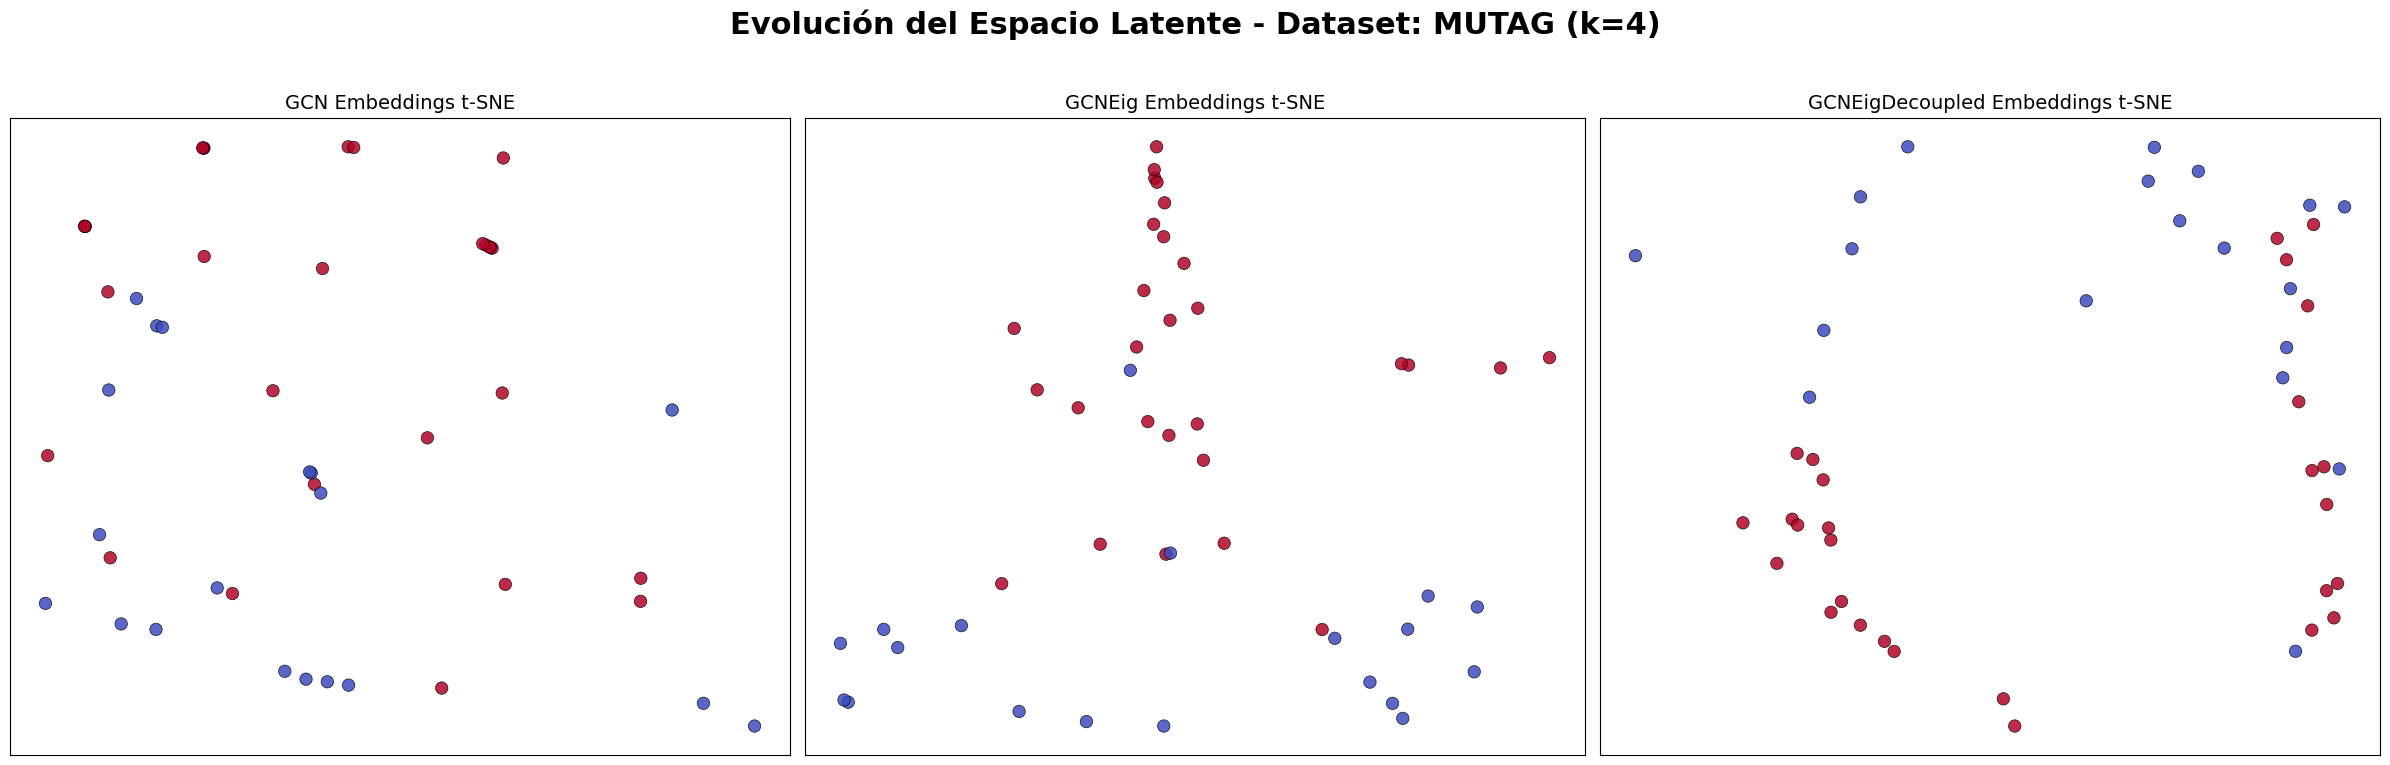

In [ ]:
# Get a fresh batch from test_loader for consistent visualization
data_for_viz = next(iter(test_loader)).to(device)

# GCN Model (global_best_models[0][0])
best_gcn_model = global_best_models[0][0]
out_gcn_embeddings = best_gcn_model.get_embeddings(data_for_viz.x, data_for_viz.edge_index, data_for_viz.batch)

evecs_list = []
for single_graph in data_for_viz.to_data_list():
    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k_val)
    evecs_list.append(evecs_single)

evecs_for_eig = torch.cat(evecs_list, dim=0).to(device)

x_for_eig = torch.cat([data_for_viz.x, evecs_for_eig], dim=1)

# GCNEig Model (global_best_models[1][0])
best_gcn_eig_model = global_best_models[1][0]
out_gcn_eig_embeddings = best_gcn_eig_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)

# GCNEigDecoupled Model (global_best_models[2][0])
best_gcn_eig_decoupled_model = global_best_models[2][0]
out_gcn_eig_decoupled_embeddings = best_gcn_eig_decoupled_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)


# TSNE Transformation
tsne = TSNE(n_components=2, random_state=12345, init='pca', learning_rate='auto')

tsne_gcn = tsne.fit_transform(out_gcn_embeddings.detach().cpu().numpy())
tsne_gcn_eig = tsne.fit_transform(out_gcn_eig_embeddings.detach().cpu().numpy())
tsne_gcn_decoupled = tsne.fit_transform(out_gcn_eig_decoupled_embeddings.detach().cpu().numpy())

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# GCN
axs[0].set_title('GCN Embeddings t-SNE', fontsize=14)
scatter0 = axs[0].scatter(tsne_gcn[:,0], tsne_gcn[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEig
axs[1].set_title('GCNEig Embeddings t-SNE', fontsize=14)
axs[1].scatter(tsne_gcn_eig[:,0], tsne_gcn_eig[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEigDecoupled
axs[2].set_title('GCNEigDecoupled Embeddings t-SNE', fontsize=14)
axs[2].scatter(tsne_gcn_decoupled[:,0], tsne_gcn_decoupled[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Evolución del Espacio Latente - Dataset: ENZYMES (k={k_val})', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.show()

* **`GCN` (Izquierda):** La distribución de las moléculas (mutagénicas vs. no mutagénicas) aparece muy mezclada. La carencia de información geométrica impide a la red trazar una frontera de decisión clara, justificando su bajo rendimiento.
* **`GCNEig` (Centro):** Se aprecia una mejor agrupación de las clases, especialmente en las zonas periféricas. Añadir geometría permite a la red identificar patrones estructurales útiles, aunque persiste cierto solapamiento en la región central del espacio latente.
* **`GCNEigDecoupled` (Derecha):** Es la representación más limpia y polarizada. Las clases están notablemente mejor separadas, lo que demuestra que procesar la química y la geometría de forma independiente (desacoplada) genera características mucho más discriminativas y precisas.

### Conclusión Final:

* **El Ganador Absoluto:** El modelo **`GCNEig` con $k=2$** se consolida como la mejor arquitectura del estudio. Al lograr una precisión en prueba del **81.70%**.

Por último, la arquitectura GatedGCN combinada con el método de codificación posicional profundo propuesto en la tesis da un *accuracy* en validación de 87.80\% ± 2.78 del cual nos quedamos muy cerca con la run del modelo Net (87,23\%) aunque algo más lejos con nuestras arquitecturas. Siendo nuestro mejor resultado la GCNEig de 32 canales ocultos con 3 capas, global mean pool y $k=2$ que nos da 81.70 ± 5.96, nos quedamos a menos de 6 puntos porcentuales de la referencia.